In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_style('whitegrid', rc={'ytick.left': True, 'ytick.color': 'silver'})
plt.rcParams['axes.autolimit_mode'] = 'round_numbers'
plt.rcParams['ytick.labelcolor'] = 'black'
sns.set_palette('colorblind')

In [3]:
df = pd.read_csv('govsites.csv')
df.describe()

,transferSize,decodedBodySize,resourceCount,scriptCount,imageCount,divCount,runtime,package-0,package-0-core,package-0-uncore
count,5735.000000,5.735000e+03,5735.000000,5735.000000,5735.000000,5735.000000,5735.000000,5735.000000,5735.000000,5735.000000
mean,28584.395815,1.115327e+05,38.597210,21.498692,11.487358,135.927637,4.481236,2.476386,0.945814,0.000064
std,36733.673319,1.109584e+05,26.094592,17.421926,16.413214,151.917780,1.337874,2.374050,1.236160,0.000091
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,4.018513,0.000000,0.001076,0.000000
25%,9882.000000,3.912400e+04,23.000000,9.000000,4.000000,65.000000,4.162179,1.032428,0.315876,0.000000
50%,20878.000000,8.543700e+04,35.000000,18.000000,8.000000,106.000000,4.278458,1.911286,0.568399,0.000000
75%,37363.000000,1.647100e+05,53.000000,29.000000,14.000000,166.000000,4.500483,2.981873,1.095952,0.000122
max,491638.000000,1.570611e+06,220.000000,140.000000,327.000000,2146.000000,34.310280,23.697954,15.221954,0.000611


In [4]:
df['sort'] = df.groupby('url')['package-0'].transform('mean')
df = df.sort_values(by='sort', ascending=False).drop('sort', axis=1).reset_index(drop=True)

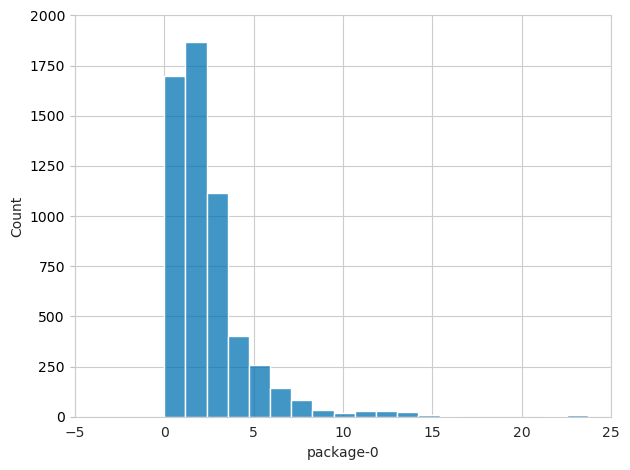

In [5]:
sns.histplot(df, x='package-0', bins=20)
plt.tight_layout()
plt.show()

In [6]:
def squash(s):
    ''' Replace everthing between outermost `/` with dots. '''
    import re
    return re.sub(r'(?<=/).*(?=/)', '...', s) if s.count('/') >= 2 else s

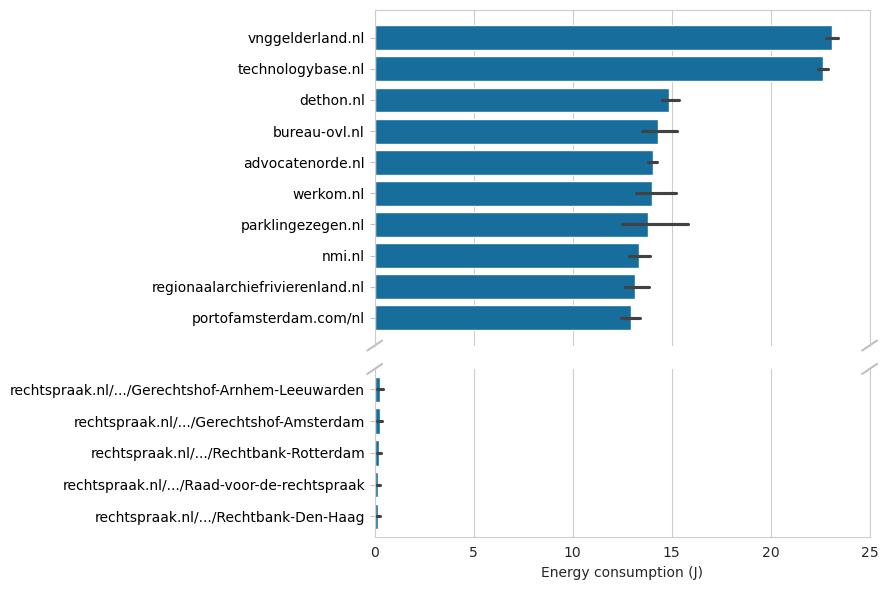

In [7]:
N_TOP, N_BOT = 10, 5
ASPECT = N_TOP / N_BOT
top, bot = df[:(5*N_TOP)], df[(-5*N_BOT):]

fig, (ax0, ax1) = plt.subplots(2, sharex=True, height_ratios=[N_TOP,N_BOT], figsize=(9,6))
sns.barplot(y=list(map(squash, top['url'])), x=top['package-0'], orient='h', ax=ax0)
sns.barplot(y=list(map(squash, bot['url'])), x=bot['package-0'], orient='h', ax=ax1)
ax1.set_xlabel('Energy consumption (J)')

# Hide spines between axes
ax0.spines['bottom'].set_visible(False)
ax1.spines['top'].set_visible(False)

# Add diagonal break marks
d = .015
kwargs = dict(transform=ax0.transAxes, color='silver', clip_on=False)
ax0.plot((0-d, 0+d), (0-d, 0+d), **kwargs) # left
ax0.plot((1-d, 1+d), (0-d, 0+d), **kwargs) # right
kwargs.update(transform=ax1.transAxes)
ax1.plot((0-d, 0+d), (1-d*ASPECT, 1+d*ASPECT), **kwargs) # left
ax1.plot((1-d, 1+d), (1-d*ASPECT, 1+d*ASPECT), **kwargs) # right

plt.tight_layout()
plt.savefig('ranking.png', bbox_inches='tight')
plt.show()